# SEEDS - 3 - Soil Health Search

This notebook combines and formalizes soil data in **Leeds**. 

The workflow is designed to be adaptable for any UK local authority, which is selected at the beginning of the notebook. However, as this project focuses on Leeds, several datasets are sourced for the region tile (not whole of UK), making parts of the analysis project-specific.

Where possible, the notebook automatically retrieves the most up-to-date available data. Some datasets are however static and have not been updated for several years, these must thus be dowloaded manually.

In [78]:
pip install matplotlib mapclassify geopandas numpy scipy folium plotly

Note: you may need to restart the kernel to use updated packages.


In [79]:
#Import packages
import pandas as pd
import seaborn as sns
import matplotlib
import matplotlib.pyplot as plt
import geopandas as gpd
import numpy as np
import folium
import mapclassify
import os

In [80]:
#Choose Local Authority to work with
LOCAL_AUTHORITY_NAME = 'Leeds' 

output_file = f'output_{LOCAL_AUTHORITY_NAME}.gpkg'

## 1- Define Local Authority Boundaries

The UK local authorities boundaries data was downloaded from [geoportal](https://geoportal.statistics.gov.uk/datasets/ons::local-authority-districts-may-2024-boundaries-uk-bfe-2/explore?location=53.495068%2C-0.354857%2C7).
The UK data is subsetted to only include the boundaries of the local authority chosen at the start, in the case of this study Leeds is chosen.

In [81]:
# Define data folder path
DATA_DIR = r'C:\Users\qxnq723\Desktop\Project_2\Datasets'

# UK local authorities file path
UK_LAD_PATH = f"{DATA_DIR}\Local_Authority_Districts_May_2024_Boundaries_UK_BFE_6583563793708892075\LAD_MAY_2024_UK_BFE.shp"

print(f"Configured for: {LOCAL_AUTHORITY_NAME}")
print(f"Data directory: {DATA_DIR}")

Configured for: Leeds
Data directory: C:\Users\qxnq723\Desktop\Project_2\Datasets


In [82]:
# Load UK Local Authority District boundaries
print("Loading UK Local Authority District boundaries...")
LAD_2024 = gpd.read_file(UK_LAD_PATH)

print(f"Loaded {len(LAD_2024)} local authority districts")
print(f"Available LADs include: {sorted(LAD_2024['LAD24NM'].unique())[:10]}...")

# Check if our chosen LAD exists 
if LOCAL_AUTHORITY_NAME in LAD_2024['LAD24NM'].values:
    print(f"Found {LOCAL_AUTHORITY_NAME} in the dataset")
    target_lad = LAD_2024[LAD_2024['LAD24NM'] == LOCAL_AUTHORITY_NAME]
    print(f"Area: {target_lad.to_crs('EPSG:27700').geometry.area.iloc[0]/1000000:.2f} km²")
else:
    print(f"{LOCAL_AUTHORITY_NAME} not found in dataset")
    print("Available LADs:", sorted(LAD_2024['LAD24NM'].unique()))

Loading UK Local Authority District boundaries...
Loaded 361 local authority districts
Available LADs include: ['Aberdeen City', 'Aberdeenshire', 'Adur', 'Amber Valley', 'Angus', 'Antrim and Newtownabbey', 'Ards and North Down', 'Argyll and Bute', 'Armagh City, Banbridge and Craigavon', 'Arun']...
Found Leeds in the dataset
Area: 551.70 km²


<Axes: >

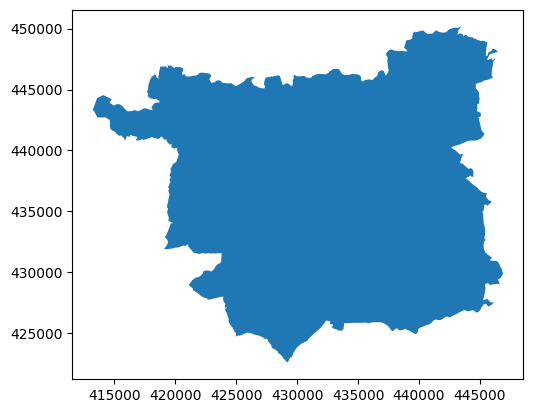

In [83]:
#Keep only chosen LA and plot it
chosen_LA = LAD_2024[LAD_2024['LAD24NM'] == LOCAL_AUTHORITY_NAME]
chosen_LA.plot()

In [84]:
#Check CRS
print(chosen_LA.crs)

EPSG:27700


In [85]:
#Create outline of chosen LA
chosen_LA['outline'] = 1
LA_outline = chosen_LA.dissolve(by= 'outline')

A function is created to subset datasets to the chosen local authority boundaries.

In [86]:
#Create function to subset data to the chosen LA
def subset_to_LAD(LAD_gdf, LAD_column_name, LAD_name, data_to_subset):
    """
    Subset a greenspace (or similar file) to only include greenspaces 
    within a chosen local authority.
    
    Parameters
    ----------
    LAD_gdf : geopandas.GeoDataFrame
        GeoDataFrame containing local authority district boundaries
    LAD_column_name : str
        Name of the column containing LAD names
    LAD_name : str
        Name of the specific LAD to subset to
    data_to_subset : geopandas.GeoDataFrame
        Data to be subset to the chosen LAD
        
    Returns
    -------
    geopandas.GeoDataFrame
        Data subset to only include features within the chosen LAD
    """
    chosen_LAD = LAD_gdf.loc[LAD_gdf[LAD_column_name] == LAD_name, :]
    chosen_LAD = chosen_LAD.to_crs(data_to_subset.crs)
    data_subset_to_LAD = data_to_subset[data_to_subset.within(chosen_LAD.union_all())]
    return data_subset_to_LAD

## 2- Geological Data - Digimap

The following geological data is downloaded from [Digimap Geology](https://digimap.edina.ac.uk/roam/map/geology).

### A- Geological Indicators of Flooding (UK - 2010)

In [87]:
#Load file
Flood = gpd.read_file(f'{DATA_DIR}\Digimap_Geology\gi-flooding_6370739\GeologicalIndicatorsFloodingGB_v6.shp')

<Axes: >

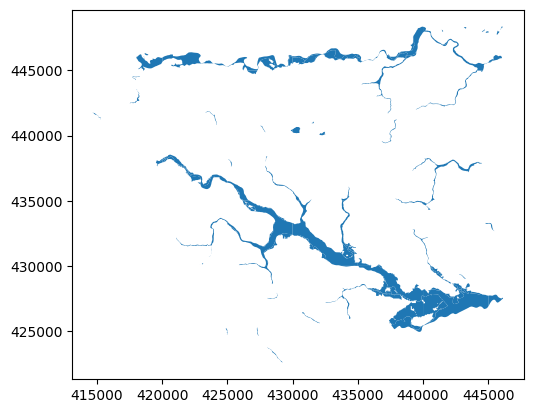

In [88]:
#Subset data to LA
flooding = gpd.clip(Flood, LA_outline)

#Check
flooding.plot()

### B- Soil Parent (SE Tile - 2019)

In [89]:
#Open all shapefiles in folder

folder_path = f'{DATA_DIR}\Digimap_Geology\soil-parent_6370741\se'

gdfs = []

#Loop through all files in folder
for file in os.listdir(folder_path):
    if file.endswith('.shp'):
        shp_path = os.path.join(folder_path, file)
        gdf = gpd.read_file(shp_path)
        gdfs.append(gdf)

#Combile all shapefiles
soil_parent = gpd.GeoDataFrame(
    pd.concat(gdfs, ignore_index=True),
    crs=gdfs[0].crs
)

soil_parent.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 74201 entries, 0 to 74200
Data columns (total 14 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   GEN_PMLITH  74201 non-null  str     
 1   ESB_DESC    74201 non-null  str     
 2   GEN_GRAIN   74201 non-null  str     
 3   SOIL_GROUP  74201 non-null  str     
 4   SOIL_DEPTH  74201 non-null  str     
 5   CACO3_RANK  74201 non-null  str     
 6   ESB_CODE    74201 non-null  str     
 7   SIMPLE_TEX  74201 non-null  str     
 8   WATER_ERZ   74201 non-null  str     
 9   WIND_ERZ    74201 non-null  str     
 10  SOIL_WASH   74201 non-null  str     
 11  Version     74201 non-null  str     
 12  UID         74201 non-null  str     
 13  geometry    74201 non-null  geometry
dtypes: geometry(1), str(13)
memory usage: 7.9 MB


In [90]:
#Subset data to LA
soil_parent = gpd.clip(soil_parent, LA_outline)

In [91]:
soil_parent.head()

,GEN_PMLITH,ESB_DESC,GEN_GRAIN,SOIL_GROUP,SOIL_DEPTH,CACO3_RANK,ESB_CODE,SIMPLE_TEX,WATER_ERZ,WIND_ERZ,SOIL_WASH,Version,UID,geometry
30984,MUDSTONE-SANDSTONE,MUDSTONE AND SANDSTONE,ARGILLIC - ARENACEOUS,HEAVY TO MEDIUM,INTERMEDIATE-SHALLOW,NONE,131_121,CLAYEY LOAM TO SANDY LOAM,Moderate. Rills may form during very wet perio...,Soil is not prone to wind erosion,Run off seen in some years during wet periods,v6.1,bgsn:SPMv61_1322255,"POLYGON ((428464.965 423360.581, 428468.981 42..."
30739,MUDSTONE-SANDSTONE,MUDSTONE AND SANDSTONE,ARGILLIC - ARENACEOUS,HEAVY TO MEDIUM,INTERMEDIATE-SHALLOW,NONE,131_121,CLAYEY LOAM TO SANDY LOAM,"Low. Sediment rarely seen to move, but be awar...",Soil is not prone to wind erosion,Run off seen in some years during VERY wet per...,v6.1,bgsn:SPMv61_1319103,"POLYGON ((429098 422718, 429087 422730, 429069..."
34692,SANDSTONE,SANDSTONE,ARENACEOUS,MEDIUM TO HEAVY,SHALLOW,NONE,121,LOAM TO SANDY LOAM,High. Rills likely to form during very wet per...,Soil may be prone to wind erosion,Run off seen in some years during wet periods,v6.1,bgsn:SPMv61_1979458,"POLYGON ((428975 422956.831, 428956.991 422975..."
34947,SANDSTONE,SANDSTONE,ARENACEOUS,MEDIUM TO HEAVY,SHALLOW,NONE,121,LOAM TO SANDY LOAM,Low-moderate. Rarely rills may form during ver...,Soil may be prone to wind erosion,Run off seen in some years during VERY wet per...,v6.1,bgsn:SPMv61_1981987,"POLYGON ((431755.108 425575, 431775 425554.416..."
31056,MUDSTONE-SANDSTONE,MUDSTONE AND SANDSTONE,ARGILLIC - ARENACEOUS,HEAVY TO MEDIUM,INTERMEDIATE-SHALLOW,NONE,131_121,CLAYEY LOAM TO SANDY LOAM,Moderate. Rills may form during very wet perio...,Soil is not prone to wind erosion,Run off seen in some years during wet periods,v6.1,bgsn:SPMv61_1322347,"POLYGON ((431258 425480, 431265.687 425483.048..."


In [92]:
soil_parent['SOIL_GROUP'].value_counts()

SOIL_GROUP
LIGHT(SILTY) TO MEDIUM(SILTY) TO HEAVY    1962
MEDIUM TO HEAVY                           1520
LIGHT(SILTY) TO MEDIUM(SILTY)             1081
MEDIUM TO LIGHT(SILTY) TO HEAVY            702
LIGHT(SANDY) TO MEDIUM(SANDY)              480
HEAVY TO MEDIUM                            395
ALL                                        346
MEDIUM(SILTY)                               72
MEDIUM                                      32
MEDIUM TO LIGHT(SILTY)                      17
Name: count, dtype: int64

In [93]:
soil_parent['GEN_GRAIN'].value_counts()

GEN_GRAIN
ARGILLIC - ARENACEOUS         2898
ARENACEOUS                    2640
MIXED (ARGILLIC-RUDACEOUS)     694
ARENACEOUS - RUDACEOUS         286
ARGILLACEOUS                    80
PEAT                             9
Name: count, dtype: int64

In [94]:
soil_parent['ESB_DESC'].value_counts()

ESB_DESC
SANDSTONE                                         2640
MUDSTONE AND SANDSTONE                            2049
GLACIAL TILL                                       681
DOLOSTONE                                          314
RIVERINE CLAY AND FLOODPLAIN SANDS AND GRAVEL      289
COLLUVIUM                                          206
RIVER TERRACE SAND/GRAVEL                          156
GLACIOFLUVIAL DEPOSITS                             126
CLAYSTONE/MUDSTONE                                  73
LIMESTONE                                           32
UNCONSOLIDATED FLUVIAL AND GLACIGENIC DEPOSITS      13
PEAT                                                 9
GLACIOLACUSTRINE                                     7
UNCONSOLIDATED GLACIAL DEPOSITS                      5
FLOODPLAIN SAND/GRAVEL                               4
LACUSTRINE SAND AND SILT                             3
Name: count, dtype: int64

In [95]:
soil_parent['SIMPLE_TEX'].value_counts()

SIMPLE_TEX
LOAM TO SANDY LOAM           2375
CLAYEY LOAM TO SANDY LOAM    2255
CLAYEY LOAM TO SILTY LOAM     692
SAND TO SANDY LOAM            395
LOAM TO SILTY                 314
CLAY TO SANDY LOAM            294
SANDY LOAM                    156
SILTY LOAM                     72
LOAM TO SILTY LOAM             32
VARIED, LOCALLY PEATY          13
PEAT                            9
Name: count, dtype: int64

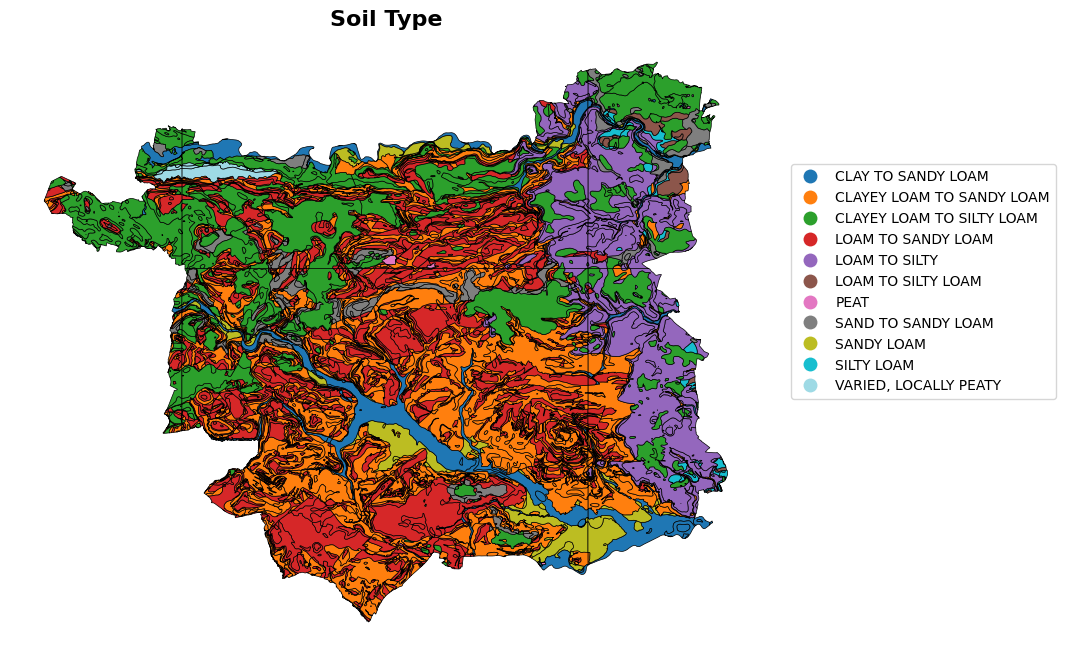

In [96]:
#Create map of soil type

#Choose which description to map
column = 'SIMPLE_TEX'

fig, ax = plt.subplots(figsize=(10, 8))

soil_parent.plot(column = column,
                 categorical= True,
                 legend = True,
                 cmap= 'tab20',
                 edgecolor= 'black',
                 linewidth= 0.5,
                 ax= ax,
                 legend_kwds= {
                     'loc': 'upper right',
                     'bbox_to_anchor': (1.4, 0.8)
                 }
)

ax.set_title('Soil Type', fontsize= 16, fontweight= 'bold')
ax.set_axis_off()
plt.show()

In [97]:
#Create soil metric column
soil_parent['Soil_Metric'] = 'Soil Parent'

## 3- Land cover - Digimap

The 2024 land cover data for the SE tile was downloaded from [Digimap Environment](https://digimap.edina.ac.uk/roam/map/environment).

In [98]:
#Load file
LandCover = gpd.read_file(f'{DATA_DIR}\Digimap_LandCover_SETile\lcm-2024-vec_6387524\lcm-2024-vec_6387524.gpkg')
LandCover.head()
print(LandCover.crs)

EPSG:27700


In [99]:
#Subset data to LA
LandCover = gpd.clip(LandCover, LA_outline)

In [100]:
#Convert the _mode to integer
LandCover['_mode'] = LandCover['_mode'].astype('Int64')

In [101]:
#Add column with land cover associated with each _mode

#Create list of identifiers (based on documentation)
LC_identifiers = {
    'Deciduous woodland': 1,
    'Coniferous woodland': 2,
    'Arable': 3,
    'Improve grassland': 4,
    'Neutral grassland': 5,
    'Calcareous grassland':	6,
    'Acid grassland': 7,
    'Fen': 8,
    'Heather': 9,
    'Heather grassland': 10,
    'Bog': 11,
    'Inland rock': 12,
    'Saltwater': 13,
    'Freshwater': 14,
    'Supralittoral rock': 15,
    'Supralittoral sediment': 16,
    'Littoral  rock': 17,
    'Littoral sediment': 18,
    'Saltmarsh': 19,
    'Urban': 20,
    'Suburban': 21
}

#Reverse dictionary: ID to label
id_to_label = {v: k for k, v in LC_identifiers.items()}

#Create new column
LandCover['Land_Cover_Type'] = LandCover['_mode'].map(id_to_label)
LandCover.head()


,_conf,_hist,_mode,_n,_purity,_stdev,_agg,gid,geometry,Land_Cover_Type
261013,56.76,"1:9,3:9,4:135,20:2,21:14",4,169,79.88,22.56,4,5460832,"MULTIPOLYGON (((424823.61 425230.08, 424825.44...",Improve grassland
222059,57.88,"1:15,3:4,4:3,20:3,21:41",21,66,62.12,19.44,10,4643857,"POLYGON ((424845.391 425302.807, 424871.35 425...",Suburban
147252,62.08,"4:13,20:4,21:56",21,73,76.71,16.19,10,3087901,"MULTIPOLYGON (((424823.222 425229.929, 424816....",Suburban
309443,57.64,"1:9,3:36,4:49,20:12,21:175",21,281,62.28,21.82,10,6477587,"POLYGON ((424718.629 425342.699, 424723.698 42...",Suburban
177521,79.28,"4:71,21:43",4,114,62.28,20.26,4,3721705,"POLYGON ((424931.28 425538.854, 424828.41 4254...",Improve grassland


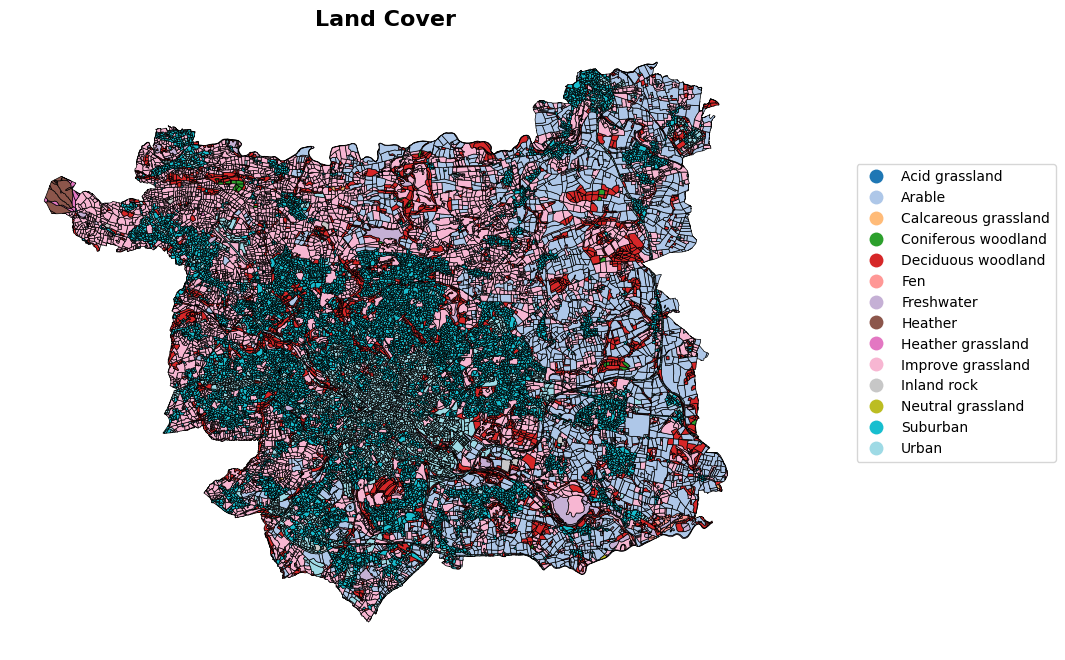

In [102]:
#Create map of land cover

fig, ax = plt.subplots(figsize=(10, 8))

LandCover.plot(column = 'Land_Cover_Type',
                 categorical= True,
                 legend = True,
                 cmap= 'tab20',
                 edgecolor= 'black',
                 linewidth= 0.5,
                 ax= ax,
                 legend_kwds= {
                     'loc': 'upper right',
                     'bbox_to_anchor': (1.4, 0.8)
                 }
)

ax.set_title('Land Cover', fontsize= 16, fontweight= 'bold')
ax.set_axis_off()
plt.show()

In [103]:
#Create soil metric column
LandCover['Soil_Metric'] = 'Land Cover'

## 4 - Soil Chemistry (Heavy Metals UKSO Data)

The heavy metals data was dowloaded for the whole of the UK from the [UKSO UK topsoil geochemistry dataset](https://www.ukso.org/static-maps/uk-topsoil-geochemistry.html), which combines data from five different topsoil survey projects spanning from 1978 to 2014.

In [104]:
pip install rasterio

Note: you may need to restart the kernel to use updated packages.


In [105]:
#Build one combined dataset with all heavy metals 
# and
#Convert Geotiff raster into vector polygons geometries

#Import libraries
import rasterio #to open GeoTIFF files and raster data
from rasterio.features import shapes #to convert raster to polygons
from pathlib import Path #file/folder handling

#Create path to folder with heavy metal files
folder_path = Path(rf'{DATA_DIR}\UKSO_HeavyMetals')

#Create empty list to contain the GeoDataFrames
all_gdfs = []

#Loop through every subfolder for tif files
for tif_path in folder_path.rglob("*.tif"):
    print(f"Processing: {tif_path.name}")
    
    #Extract name of heavymetal from subfolders string
    subfolder_name = tif_path.parent.name
    metal = subfolder_name.split('geotiff_')[1].split('_v1')[0]

    #Open GeoTIFF file, and read band 1 into array 
    # (TIFF files have only 1 band)
    with rasterio.open(tif_path) as source:
        raster = source.read(1)
        
        #Convert raster data into polygons
        # s = polygon geometry
        # v = raster value
        results = (
            {'properties': {'value': v}, 
             'geometry': s}
            for s , v in shapes(raster, transform= source.transform) # convert pixel coordinates into real-world coordinates
            if v != source.nodata #skip pixels with no data
        )


        #Convert all polygon features into list and then into a GeoDataFrame
        gdf= gpd.GeoDataFrame.from_features(list(results))
        #Assign UK 27700 CRS
        gdf.set_crs(source.crs, inplace= True)
        
        #Track source file
        gdf['source_file'] = tif_path.stem
        #Add metal name column
        gdf['metal'] = metal
        #Add the GeoDataFrame into master list (1 GeoDataFrame per TIFF)
        all_gdfs.append(gdf)

#Convert into big table
HeavyMetals = pd.concat(all_gdfs, ignore_index = True)
HeavyMetals = gpd.GeoDataFrame(HeavyMetals, geometry= 'geometry')
HeavyMetals.head()

Processing: As_v1.tif
Processing: Cd_v1.tif
Processing: Cu_v1.tif
Processing: Ni_v1.tif
Processing: P2O5_v1.tif
Processing: Pb_v1.tif
Processing: Se_v1.tif
Processing: Zr_v1.tif


,geometry,value,source_file,metal
0,"POLYGON ((239500 685500, 239500 685000, 240000...",13.14662,As_v1,As
1,"POLYGON ((240500 685500, 240500 685000, 241000...",13.33386,As_v1,As
2,"POLYGON ((239500 685000, 239500 684500, 240000...",13.33047,As_v1,As
3,"POLYGON ((240000 685000, 240000 684500, 240500...",13.56266,As_v1,As
4,"POLYGON ((240500 685000, 240500 684500, 241000...",13.60579,As_v1,As


In [106]:
HeavyMetals.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 5341907 entries, 0 to 5341906
Data columns (total 4 columns):
 #   Column       Dtype   
---  ------       -----   
 0   geometry     geometry
 1   value        float64 
 2   source_file  str     
 3   metal        str     
dtypes: float64(1), geometry(1), str(2)
memory usage: 163.0 MB


In [107]:
HeavyMetals['metal'].value_counts()

metal
Ni      672307
As      672292
Pb      672266
Zr      672259
Se      672245
Cu      671982
Cd      671776
P2O5    636780
Name: count, dtype: int64

In [108]:
#Subset data to LA
HeavyMetals = gpd.clip(HeavyMetals, LA_outline)

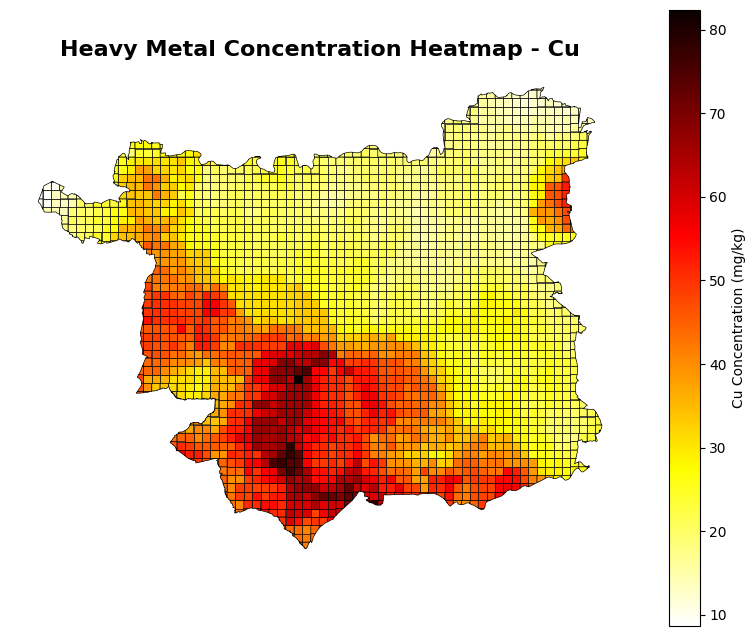

In [109]:
#Create map of heavy metal

#Choose which heavy metal to map
plot_metal = 'Cu'
#Filter dataset for that metal only
m = HeavyMetals[HeavyMetals['metal'] == plot_metal]

fig, ax = plt.subplots(figsize=(10, 8))

m.plot(column = 'value',
       legend = True,
       cmap= 'hot_r',
       edgecolor= 'black',
       linewidth= 0.5,
       ax= ax,
       legend_kwds= {'label': f'{plot_metal} Concentration (mg/kg)'}
)

ax.set_title(f'Heavy Metal Concentration Heatmap - {plot_metal}', 
             fontsize= 16, 
             fontweight= 'bold')
ax.set_axis_off()
plt.show()

In [110]:
#Add the unit of each heavy metal (are not all the same)
units= {
    'Ni': 'mg/kg',
    'As': 'mg/kg',
    'Pb': 'mg/kg',
    'Zr': 'mg/kg',
    'Se': 'mg/kg',
    'Cu': 'mg/kg',
    'Cd': 'mg/kg',
    'P2O5': 'w%',
}

HeavyMetals['HM_unit'] = HeavyMetals['metal'].map(units)

In [111]:
#Add the unit of each heavy metal (are not all the same)
name_metal= {
    'Ni': 'Nickel',
    'As': 'Arsenic',
    'Pb': 'Lead',
    'Zr': 'Zirconium',
    'Se': 'Selenium',
    'Cu': 'Copper',
    'Cd': 'Cadmium',
    'P2O5': 'Phosphorus',
}

HeavyMetals['HM_name'] = HeavyMetals['metal'].map(name_metal)

In [112]:
#Create soil metric column
HeavyMetals['Soil_Metric'] = 'Heavy Metals'

## 5- Soil pH - UKSO

The UK soil pH data was dowloaded from [UKSO topsoil pH](https://catalogue.ceh.ac.uk/documents/5dd624a9-55c9-4cc0-b366-d335991073c7), which were collected and analysed in 2007.

In [113]:
Soil_pH = gpd.read_file(rf'{DATA_DIR}\UKSO_Soil_pH\data\CS_topsoil_pH_bulkDensity.shp')
Soil_pH.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 1385 entries, 0 to 1384
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   LCM_CLASS   1385 non-null   str     
 1   LCM_NUMBER  1385 non-null   int32   
 2   DOM_GRAIN   1385 non-null   str     
 3   SOIL_GROUP  1385 non-null   str     
 4   CACO3_RANK  1385 non-null   str     
 5   BULKD_07    1385 non-null   float64 
 6   BULKD_07SE  1385 non-null   float64 
 7   PH_78       1385 non-null   float64 
 8   PH_78SE     1385 non-null   float64 
 9   PH_98       1385 non-null   float64 
 10  PH_98SE     1385 non-null   float64 
 11  PH_07       1385 non-null   float64 
 12  PH_07SE     1385 non-null   float64 
 13  SHAPE_AREA  1385 non-null   float64 
 14  SHAPE_LEN   1385 non-null   float64 
 15  geometry    1385 non-null   geometry
dtypes: float64(10), geometry(1), int32(1), str(4)
memory usage: 167.8 KB


In [114]:
print(Soil_pH.crs)

EPSG:27700


In [115]:
#Subset data to LA
Soil_pH = gpd.clip(Soil_pH, LA_outline)

In [116]:
Soil_pH.head()

,LCM_CLASS,LCM_NUMBER,DOM_GRAIN,SOIL_GROUP,CACO3_RANK,BULKD_07,BULKD_07SE,PH_78,PH_78SE,PH_98,PH_98SE,PH_07,PH_07SE,SHAPE_AREA,SHAPE_LEN,geometry
163,Broadleaved woodland,1,MUD,HEAVY TO MEDIUM,NONE,0.759731,0.023147,4.833214,0.099812,5.191102,0.101680,5.501506,0.063326,15000000.0,58000.0,"POLYGON ((439000 428000, 439000 429000, 440000..."
849,Arable and Horticulture,3,SAND,MEDIUM,HIGH,1.159905,0.018035,7.583729,0.085913,7.816203,0.080098,8.210084,0.069183,420000000.0,682000.0,"POLYGON ((445000 443000, 445000 443114.7, 4450..."
309,Improved Grassland,4,MUD,HEAVY TO MEDIUM,NONE,0.960654,0.018524,5.609945,0.054099,5.880890,0.053105,6.068252,0.036514,357000000.0,954000.0,"MULTIPOLYGON (((425000 425000, 425745.143 4250..."
273,Improved Grassland,4,SAND,MEDIUM TO LIGHT(SILTY),NONE,0.937116,0.016865,5.609945,0.054099,5.880890,0.053105,6.068252,0.036514,248000000.0,674000.0,"POLYGON ((428000 446000, 428000 446070.595, 42..."
119,Broadleaved woodland,1,SAND,LIGHT(SILTY) TO MEDIUM(SILTY) TO HEAVY,NONE,0.736193,0.022400,4.833214,0.099812,5.191102,0.101680,5.501506,0.063326,87000000.0,266000.0,"MULTIPOLYGON (((428000 438000, 428000 439000, ..."


PH_98 is the 'Mean value for soil pH in 1998 modelled by LCM_CLASS and CACO3_RANK', so that is used as pH value and is mapped.

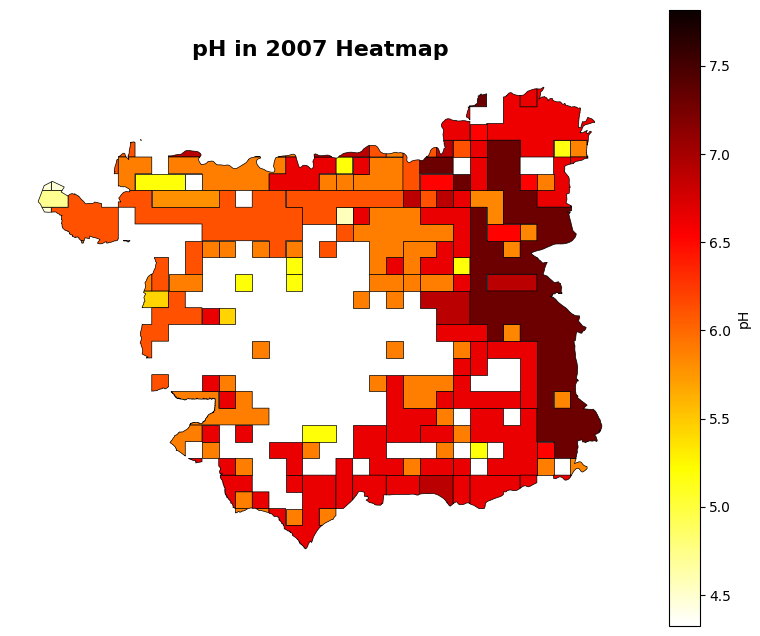

In [117]:
#Create map of pH in 2007

fig, ax = plt.subplots(figsize=(10, 8))

Soil_pH.plot(column = 'PH_98',
       legend = True,
       cmap= 'hot_r',
       edgecolor= 'black',
       linewidth= 0.5,
       ax= ax,
       legend_kwds= {'label': 'pH'}
)

ax.set_title(f'pH in 2007 Heatmap', 
             fontsize= 16, 
             fontweight= 'bold')
ax.set_axis_off()
plt.show()

In [118]:
#Create soil metric column
Soil_pH['Soil_Metric'] = 'Soil pH'

## 6- TopSoil Carbon - UKSO

The UK topsoil carbon was downloaded from [UKSO topsoil carbon](https://catalogue.ceh.ac.uk/documents/9e4451f8-23d3-40dc-9302-73e30ad3dd76), which was collected in 2007.

In [119]:
Soil_SOM = gpd.read_file(f'{DATA_DIR}/UKSO_SoilCarbon/data/9e4451f8-23d3-40dc-9302-73e30ad3dd76/CS_topsoil_carbon.shp')
Soil_SOM.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 1385 entries, 0 to 1384
Data columns (total 26 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   LCM_CLASS   1385 non-null   str     
 1   LCM_NUMBER  1385 non-null   int32   
 2   DOM_GRAIN   1385 non-null   str     
 3   SOIL_GROUP  1385 non-null   str     
 4   CACO3_RANK  1385 non-null   str     
 5   CCONC_78    1385 non-null   float64 
 6   CCONC_78SE  1385 non-null   float64 
 7   CCONC_98    1385 non-null   float64 
 8   CCONC_98SE  1385 non-null   float64 
 9   CCONC_07    1385 non-null   float64 
 10  CCONC_07SE  1385 non-null   float64 
 11  LOI_78      1385 non-null   float64 
 12  LOI_78SE    1385 non-null   float64 
 13  LOI_98      1385 non-null   float64 
 14  LOI_98SE    1385 non-null   float64 
 15  LOI_07      1385 non-null   float64 
 16  LOI_07SE    1385 non-null   float64 
 17  CDENS_78    1385 non-null   float64 
 18  CDENS_78SE  1385 non-null   float64 
 19

In [120]:
print(Soil_SOM.crs)

EPSG:27700


In [121]:
#Subset data to LA
Soil_SOM = gpd.clip(Soil_SOM, LA_outline)

In [122]:
Soil_SOM.head()

,LCM_CLASS,LCM_NUMBER,DOM_GRAIN,SOIL_GROUP,CACO3_RANK,CCONC_78,CCONC_78SE,CCONC_98,CCONC_98SE,CCONC_07,...,LOI_07SE,CDENS_78,CDENS_78SE,CDENS_98,CDENS_98SE,CDENS_07,CDENS_07SE,SHAPE_AREA,SHAPE_LEN,geometry
28,Broadleaved woodland,1,MUD,HEAVY TO MEDIUM,NONE,57.224448,13.385675,100.833131,13.362104,81.514217,...,1.640902,66.159914,3.055434,77.350750,3.123253,68.529984,1.754334,1.500000e+07,58000.0,"POLYGON ((439000 428000, 439000 429000, 440000..."
96,Broadleaved woodland,1,SAND,LIGHT(SILTY) TO MEDIUM(SILTY),NONE,68.209941,13.239136,111.818624,13.216018,92.499710,...,1.611174,66.159914,3.055434,77.350750,3.123253,68.529984,1.754334,8.000000e+07,274000.0,"POLYGON ((431000 445000, 431000 445931.912, 43..."
538,Improved Grassland,4,SAND,LIGHT(SILTY) TO MEDIUM(SILTY),NONE,58.828651,7.699216,59.179935,7.512513,60.023892,...,1.064850,66.495364,1.619332,68.940971,1.554884,72.407370,0.969125,8.360000e+08,1896000.0,"MULTIPOLYGON (((423000 430000, 423000 429000, ..."
543,Arable and Horticulture,3,SAND,LIGHT(SILTY) TO MEDIUM(SILTY),NONE,35.747631,8.809080,34.060466,7.776545,32.416605,...,1.098951,52.520676,2.006340,51.872363,1.662541,49.672538,1.074950,1.046000e+09,2114000.0,"POLYGON ((439551.3 425000, 439551.3 425000, 43..."
223,Arable and Horticulture,3,MUD,HEAVY TO MEDIUM,NONE,24.762138,9.137334,23.074973,8.087917,21.431112,...,1.172104,52.520676,2.006340,51.872363,1.662541,49.672538,1.074950,9.080000e+08,1698000.0,"MULTIPOLYGON (((430000 424000, 430177.499 4240..."


LOI_07 is the 'Mean value for soil loss-on-ignition in 2007 modelled by LCM_CLASS and DOM_GRAIN', which corresponds to the soil organic matter (SOM).

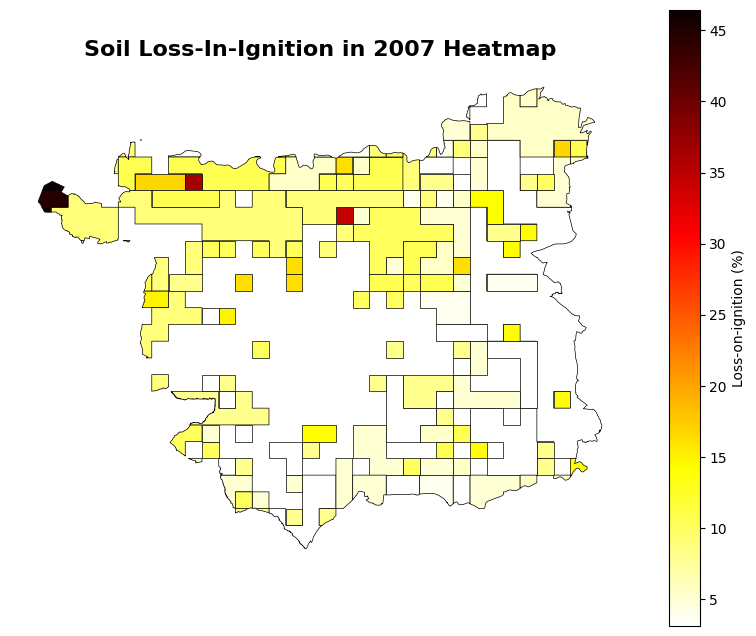

In [123]:
#Create map of SOM in 2007

fig, ax = plt.subplots(figsize=(10, 8))

Soil_SOM.plot(column = 'LOI_07',
       legend = True,
       cmap= 'hot_r',
       edgecolor= 'black',
       linewidth= 0.5,
       ax= ax,
       legend_kwds= {'label': 'Loss-on-ignition (%)'}
)

ax.set_title(f'Soil Loss-In-Ignition in 2007 Heatmap', 
             fontsize= 16, 
             fontweight= 'bold')
ax.set_axis_off()
plt.show()

In [124]:
#Create soil metric column
Soil_SOM['Soil_Metric'] = 'Soil SOM'

## 7- Create Clean Soil Health Dataset

The different datasets are combined into 1 clean soil health dataset:

In [125]:
print(soil_parent.crs)
print(LandCover.crs)
print(HeavyMetals.crs)
print(Soil_pH.crs)
print(Soil_SOM.crs)

EPSG:27700
EPSG:27700
PROJCS["OSGB36 / British National Grid",GEOGCS["OSGB36",DATUM["Ordnance_Survey_of_Great_Britain_1936",SPHEROID["Airy 1830",6377563.396,299.324964600004,AUTHORITY["EPSG","7001"]],AUTHORITY["EPSG","6277"]],PRIMEM["Greenwich",0],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4277"]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",49],PARAMETER["central_meridian",-2],PARAMETER["scale_factor",0.9996012717],PARAMETER["false_easting",400000],PARAMETER["false_northing",-100000],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH],AUTHORITY["EPSG","27700"]]
EPSG:27700
EPSG:27700


In [126]:
#Set the crs to 27700
HeavyMetals = HeavyMetals.to_crs("EPSG:27700")

In [127]:
Soil_pH.columns

Index(['LCM_CLASS', 'LCM_NUMBER', 'DOM_GRAIN', 'SOIL_GROUP', 'CACO3_RANK',
       'BULKD_07', 'BULKD_07SE', 'PH_78', 'PH_78SE', 'PH_98', 'PH_98SE',
       'PH_07', 'PH_07SE', 'SHAPE_AREA', 'SHAPE_LEN', 'geometry',
       'Soil_Metric'],
      dtype='str')

In [128]:
soil_parent['SOIL_GROUP'].unique()

<StringArray>
[                       'HEAVY TO MEDIUM',
                        'MEDIUM TO HEAVY',
                                    'ALL',
        'MEDIUM TO LIGHT(SILTY) TO HEAVY',
 'LIGHT(SILTY) TO MEDIUM(SILTY) TO HEAVY',
          'LIGHT(SILTY) TO MEDIUM(SILTY)',
          'LIGHT(SANDY) TO MEDIUM(SANDY)',
                 'MEDIUM TO LIGHT(SILTY)',
                          'MEDIUM(SILTY)',
                                 'MEDIUM']
Length: 10, dtype: str

In [129]:
soil_parent_to_join= soil_parent[['GEN_GRAIN', 'SOIL_GROUP', 'geometry', 'Soil_Metric']].copy()
LandCover_to_join= LandCover[['geometry', 'Land_Cover_Type','Soil_Metric']].copy()
HeavyMetals_to_join= HeavyMetals[['geometry', 'value', 'metal', 'HM_unit', 'HM_name', 'Soil_Metric']].copy()
Soil_pH_to_join= Soil_pH[['PH_98', 'geometry', 'Soil_Metric']]
Soil_SOM_to_join= Soil_SOM[['LOI_07', 'geometry', 'Soil_Metric']]

# Combine different soil health data
soil_health = pd.concat([soil_parent_to_join, LandCover_to_join, HeavyMetals_to_join, Soil_pH_to_join, Soil_SOM_to_join], ignore_index=True)
soil_health.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 51939 entries, 0 to 51938
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype   
---  ------           --------------  -----   
 0   GEN_GRAIN        6607 non-null   str     
 1   SOIL_GROUP       6607 non-null   str     
 2   geometry         51939 non-null  geometry
 3   Soil_Metric      51939 non-null  str     
 4   Land_Cover_Type  26549 non-null  str     
 5   value            18697 non-null  float64 
 6   metal            18697 non-null  str     
 7   HM_unit          18697 non-null  str     
 8   HM_name          18697 non-null  str     
 9   PH_98            43 non-null     float64 
 10  LOI_07           43 non-null     float64 
dtypes: float64(3), geometry(1), str(7)
memory usage: 4.4 MB


In [130]:
soil_health['Soil_Metric'].value_counts()

Soil_Metric
Land Cover      26549
Heavy Metals    18697
Soil Parent      6607
Soil pH            43
Soil SOM           43
Name: count, dtype: int64

In [131]:
#Save the clean soil health datasets, to map soil health over the whole of Leeds
#Save Locally
soil_health.to_file((os.path.join(DATA_DIR, "soil_health.gpkg")), driver='GPKG')
#Save in workspace
workspace_path= r"C:\Users\qxnq723\Desktop\Project_2\Dashboard Development"
soil_health.to_file((os.path.join(workspace_path, "Data", "Processed_Data", "soil_health.gpkg")), driver='GPKG')

## 8- Link Existing CGSs to their corresponding soil health

In [132]:
#Load the existing CGSs data
exist_CGS = gpd.read_file(r"C:\Users\qxnq723\Desktop\Project_2\Dashboard Development\Data\Processed_Data\Existing_CGSs.gpkg")
exist_CGS.head()

,flag,Type,Name,Management,Organisation,Activity_Description,Entry_Conditions,Day_and_Time_(LGAP),Ongoing_or_set_programs?_(LGAP),All_year_or_seasonal?_(LGAP),...,Toilets_(LGAP),Indoor_Space_(LGAP),Indoor_Type_(LGAP),Transport_Support_(LGAP),Contact_Name,Email,Phone_Number_(LGAP),Website_Link,id,geometry
0,FWL,Composting Collective,Chapel Allerton Composting In The Park,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,Annie Whitehead OR Lukas and Katie at The Frui...,anniewhiteheadLeeds@gmail.com | Katy.daniel@ho...,NaN,NaN,LEEDS_392f971be18a,POINT (430790 437434)
1,FWL,Composting Collective,The Involve Centre,NaN,The Involve Centre,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,Annie Whitehead,anniewhiteheadLeeds@gmail.com |Penny@Involve.o...,NaN,NaN,LEEDS_5ae255dcaf6e,POINT (431182 431633)
2,FWL,Composting Collective,Friends Of Hunslet Moor,NaN,Friends of Hunslet Moor Hub,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,Sam Gilmore,Sgilmore51@icloud.com,NaN,NaN,LEEDS_102d87852220,POINT (430294 431776)
3,FWL,Composting Collective,The Welcome In,NaN,OPAL (Older People's Active Learning Centre).,Now intergenerational with a toddler group.,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,Ellen Stoker,Ellen@opal-project.org.uk,NaN,NaN,LEEDS_b12fb584bf6f,POINT (425220 439259)
4,FWL,Composting Collective,Garforth,NaN,Incredible Edible,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,Jacky Simpson,jacquelinesimpson@btinternet.com,NaN,NaN,LEEDS_a1254fcf6232,POINT (441097 433203)


In [133]:
#The existing CGSs are spatially joined to the soil health data

CGS_soil = gpd.sjoin(
    exist_CGS,
    soil_health,
    predicate='intersects',
    how='left'
)

In [134]:
#Keep only the CGS id, name and soil health metrics
CGS_soil = CGS_soil[['id', 
                     'Name', 
                     'GEN_GRAIN', 
                     'SOIL_GROUP',
                     'Soil_Metric',
                     'Land_Cover_Type',
                     'value',
                     'metal',
                     'HM_unit',
                     'HM_name',
                     'PH_98',
                     'LOI_07']]
CGS_soil.info()

<class 'pandas.DataFrame'>
Index: 5033 entries, 0 to 354
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id               5033 non-null   str    
 1   Name             4540 non-null   str    
 2   GEN_GRAIN        530 non-null    str    
 3   SOIL_GROUP       530 non-null    str    
 4   Soil_Metric      5029 non-null   str    
 5   Land_Cover_Type  690 non-null    str    
 6   value            3571 non-null   float64
 7   metal            3571 non-null   str    
 8   HM_unit          3571 non-null   str    
 9   HM_name          3571 non-null   str    
 10  PH_98            119 non-null    float64
 11  LOI_07           119 non-null    float64
dtypes: float64(3), str(9)
memory usage: 511.2 KB


In [135]:
CGS_soil.head()

,id,Name,GEN_GRAIN,SOIL_GROUP,Soil_Metric,Land_Cover_Type,value,metal,HM_unit,HM_name,PH_98,LOI_07
0,LEEDS_392f971be18a,Chapel Allerton Composting In The Park,NaN,NaN,Heavy Metals,NaN,0.267916,P2O5,w%,Phosphorus,NaN,NaN
0,LEEDS_392f971be18a,Chapel Allerton Composting In The Park,ARENACEOUS,LIGHT(SILTY) TO MEDIUM(SILTY),Soil Parent,NaN,NaN,NaN,NaN,NaN,NaN,NaN
0,LEEDS_392f971be18a,Chapel Allerton Composting In The Park,NaN,NaN,Land Cover,Suburban,NaN,NaN,NaN,NaN,NaN,NaN
0,LEEDS_392f971be18a,Chapel Allerton Composting In The Park,NaN,NaN,Heavy Metals,NaN,22.644390,Ni,mg/kg,Nickel,NaN,NaN
0,LEEDS_392f971be18a,Chapel Allerton Composting In The Park,NaN,NaN,Heavy Metals,NaN,17.759830,As,mg/kg,Arsenic,NaN,NaN
